# 4. Inventory and returns analysis

**Business questions:** which stock is short, which is surplus, and how much money is tied up? Which categories and reasons drive returns?

*Health classes are project assumptions* (documented in `docs/06_inventory_metrics.md`): OUT_OF_STOCK, DEAD_STOCK (no sale at the store in 365 days), LOW_STOCK (at or below reorder level), OVERSTOCKED (above max level or more than 180 days of cover), HEALTHY.

In [1]:
import sys
sys.path.insert(0, "..")            # make the modules in python/ importable from this folder
import pandas as pd
import matplotlib.pyplot as plt
import visualization as viz
from data_extraction import get_view
pd.set_option("display.width", 160, "display.max_columns", 20, "display.float_format", "{:,.1f}".format)
%matplotlib inline

In [2]:
import inventory_analysis as ia, product_analysis as pa
inv = get_view('vw_inventory_health')
products = get_view('vw_product_performance')
cats = get_view('vw_category_performance')
returns = get_view('vw_return_analysis')

## Stock health

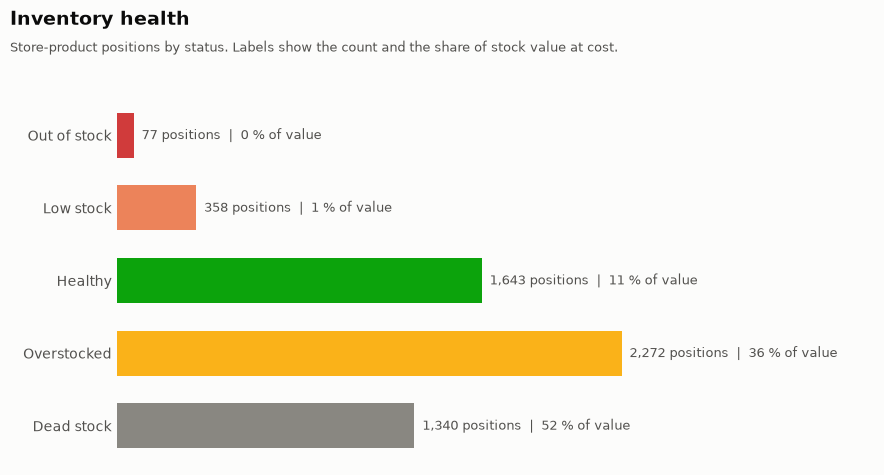

,health_status,positions,units,value_at_cost,position_share_pct,value_share_pct
0,OUT_OF_STOCK,77,0,0.0,1.4,0.0
1,LOW_STOCK,358,758,"690,760.8",6.3,1.1
2,HEALTHY,1643,9158,"6,944,346.1",28.9,11.1
3,OVERSTOCKED,2272,17711,"22,538,251.9",39.9,35.9
4,DEAD_STOCK,1340,16309,"32,574,847.2",23.6,51.9


In [3]:
viz.inventory_health(inv); plt.show()
ia.health_summary(inv)

## Store risk: stock-out risk versus surplus capital

In [4]:
ia.store_risk(inv)

,store_name,positions,at_risk_positions,inventory_value,surplus_value,stock_out_risk_pct,surplus_share_pct
0,Lucknow Gomti Nagar,472,33,"6,342,551.3","6,107,105.7",7.0,96.3
1,Online Fulfilment Hub,568,66,"7,287,100.3","5,611,389.5",11.6,77.0
2,Chandigarh Sector 17,456,17,"5,246,483.2","4,989,711.3",3.7,95.1
3,Mumbai Andheri,465,40,"5,504,814.8","4,842,162.0",8.6,88.0
4,Hyderabad Banjara Hills,473,39,"5,004,679.9","4,574,416.0",8.2,91.4
5,Pune Koregaon Park,464,29,"5,099,771.2","4,519,449.8",6.2,88.6
6,Ahmedabad SG Highway,470,38,"4,824,134.5","4,423,028.8",8.1,91.7
7,Jaipur Malviya Nagar,456,21,"4,922,768.9","4,384,376.2",4.6,89.1
8,Kolkata Salt Lake,469,37,"4,554,965.8","4,087,245.0",7.9,89.7
9,Chennai T Nagar,475,40,"4,591,914.6","4,079,795.2",8.4,88.8


## Stock aging and cover

In [5]:
ia.aging(inv)

,stock_age,positions,value_at_cost,value_share_pct
0,0-30 days,961,"4,834,939.4",7.7
1,31-90 days,1243,"6,684,713.8",10.7
2,91-180 days,620,"3,840,359.0",6.1
3,181-365 days,722,"5,200,572.4",8.3
4,over 365 days,2067,"42,187,621.4",67.2


In [6]:
ia.coverage_bands(inv)

,cover,positions,value_at_cost,position_share_pct
0,under 7 days,106,"29,035.9",3.4
1,7-29 days,307,"510,764.2",9.7
2,30-89 days,1045,"3,897,585.9",33.0
3,90-179 days,818,"4,538,919.8",25.9
4,180+ days,888,"8,409,000.2",28.1


## Turnover by category
Simplified: cost of goods sold in the last 12 months divided by current inventory value (ending-inventory approximation).

In [7]:
ia.turnover_by_category(products)

,category,cogs_12m,inventory_value,inventory_turnover,days_of_inventory
0,Grocery & Staples,"5,467,073.7","835,229.8",6.5,55.8
1,Beverages,"2,628,847.1","522,954.8",5.0,72.6
2,Personal Care,"2,644,986.1","768,794.2",3.4,106.1
3,Mobiles & Accessories,"7,122,862.8","3,623,415.2",2.0,185.7
4,Women's Clothing,"3,667,048.9","2,460,645.5",1.5,244.9
5,Men's Clothing,"3,730,231.0","2,736,703.2",1.4,267.8
6,Footwear,"2,621,653.9","2,431,145.6",1.1,338.5
7,(no category),"252,264.6","491,804.2",0.5,711.6
8,Sports & Fitness,"2,409,394.5","4,826,970.3",0.5,731.2
9,Kids' Wear,"636,395.2","1,678,548.4",0.4,962.7


## Product classes: revenue versus stock

In [8]:
ia.product_classes(products)

,product_class,products,inventory_value
0,High Revenue / Healthy Stock,95,"5,377,130.8"
1,High Revenue / Low Stock,5,"227,955.8"
2,Low Revenue / High Stock,231,"27,251,478.5"
3,Other,305,"29,891,641.0"


## Replenishment list
Positions that sold in the last 90 days and are at or below reorder level. Suggested quantity subtracts stock already on open purchase orders.

In [9]:
ia.replenishment_list(inv, 15)

,store_name,product_name,quantity_on_hand,reorder_level,avg_daily_demand,inbound_quantity,suggested_order_qty
0,Online Fulfilment Hub,Annadata Pure Ghee 1L Pack of 2,15,19,2.3,55,1
1,Delhi Connaught Place,Annadata Pure Ghee 1L Pack of 2,4,16,1.2,46,11
2,Online Fulfilment Hub,Mangal Toor Dal 1kg Value Pack,5,12,1.1,33,7
3,Hyderabad Banjara Hills,Annadata Pure Ghee 1L Pack of 2,14,14,0.8,39,0
4,Online Fulfilment Hub,Khet Fresh Masala Combo Value Pack,0,13,0.8,26,13
5,Bengaluru Indiranagar,Golden Grain Instant Noodles Pack Value Pack,3,7,0.7,24,0
6,Online Fulfilment Hub,Mangal Instant Noodles Pack Value Pack,2,6,0.7,19,4
7,Bengaluru Indiranagar,Khet Fresh Masala Combo Value Pack,5,9,0.7,20,2
8,Mumbai Andheri,Brewly Coffee Powder 200g Zero Sugar,12,14,0.7,30,0
9,Online Fulfilment Hub,Pacer Ankle Boots UK 6,7,9,0.7,25,1


## Returns
*Recorded* reasons only: the data shows what was recorded at the counter, not why the customer really returned the item.

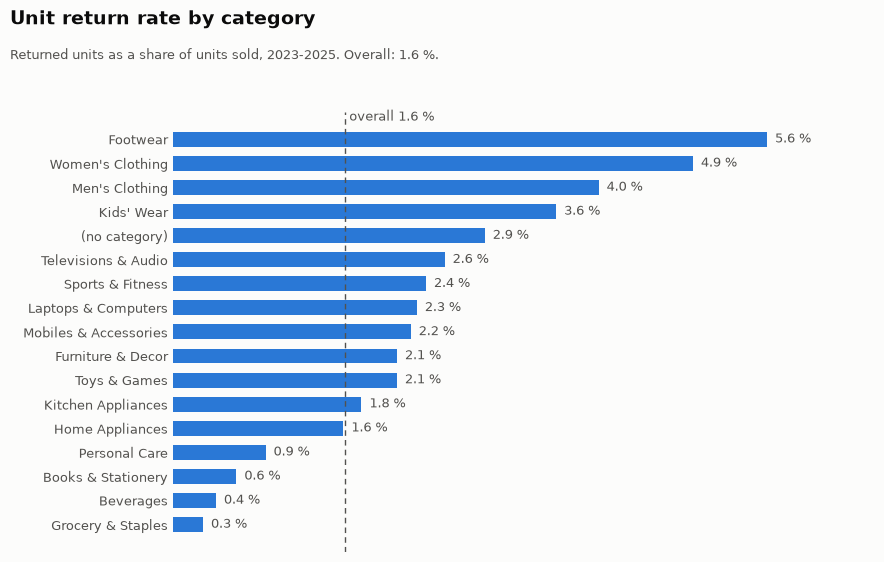

,return_reason,return_lines,units,refund_net,share_pct
0,SIZE_ISSUE,721,769,"807,624.1",24.9
1,CHANGED_MIND,577,661,"868,485.3",19.9
2,DEFECTIVE,517,567,"767,642.4",17.8
3,NOT_AS_DESCRIBED,474,511,"650,772.0",16.3
4,WRONG_ITEM,265,298,"296,890.7",9.1
5,DAMAGED_IN_TRANSIT,212,222,"234,103.3",7.3
6,OTHER,135,152,"278,149.2",4.7


In [10]:
viz.return_rate_by_category(cats); plt.show()
pa.return_reasons(returns)